# NLP: Классификация тональности отзывов IMDB
Сравнение трёх подходов: TF-IDF + LR (baseline), BiLSTM (random embeddings),BiLSTM + GloVe

## 1. Загрузка данных

In [26]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("stanfordnlp/imdb")

train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

print("Train:", train_df.shape)
print("Test:", test_df.shape)

train_df.head()


Train: (25000, 2)
Test: (25000, 2)


,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


## 2. EDA

Пропуски:
text     0
label    0
dtype: int64

Дубликаты: 96

Распределение классов:
label
0    12500
1    12500
Name: count, dtype: int64


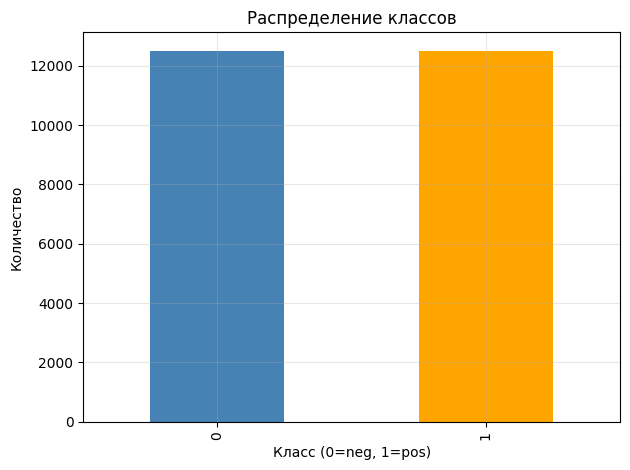

In [27]:
import matplotlib.pyplot as plt

print("Пропуски:")
print(train_df.isnull().sum())
print("\nДубликаты:", train_df.duplicated().sum())
print("\nРаспределение классов:")
print(train_df["label"].value_counts())

train_df["label"].value_counts().plot(kind="bar", color=["steelblue", "orange"])
plt.title("Распределение классов")
plt.xlabel("Класс (0=neg, 1=pos)")
plt.ylabel("Количество")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Предобработка текста

In [29]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)          # убираем HTML-теги
    text = re.sub(r"[^a-z\s]", " ", text)        # только буквы
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df["clean_text"] = train_df["text"].apply(clean_text)
test_df["clean_text"]  = test_df["text"].apply(clean_text)

print("Пример очищенного текста:")
print(train_df["clean_text"].iloc[0][:300])

Пример очищенного текста:
i rented i am curious yellow from my video store because of all the controversy that surrounded it when it was first released in i also heard that at first it was seized by u s customs if it ever tried to enter this country therefore being a fan of films considered controversial i really had to see 


count    25000.000000
mean       236.866080
std        176.005579
min         10.000000
25%        129.000000
50%        177.000000
75%        287.000000
max       2494.000000
Name: len, dtype: float64


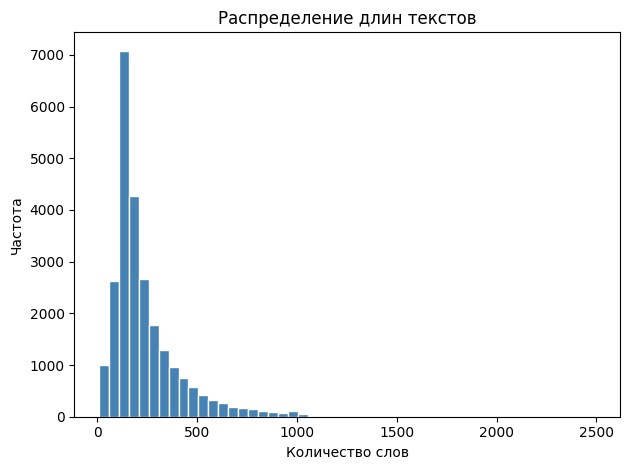


max_len (95-й перцентиль): 608


In [30]:
train_df["len"] = train_df["clean_text"].apply(lambda x: len(x.split()))

print(train_df["len"].describe())

plt.hist(train_df["len"], bins=50, color="steelblue", edgecolor="white")
plt.title("Распределение длин текстов")
plt.xlabel("Количество слов")
plt.ylabel("Частота")
plt.tight_layout()
plt.show()

max_len = int(train_df["len"].quantile(0.95))
print(f"\nmax_len (95-й перцентиль): {max_len}")

## 4. Train / Val / Test split

In [32]:
from sklearn.model_selection import train_test_split

X = train_df["clean_text"].values
y = train_df["label"].values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_test = test_df["clean_text"].values
y_test = test_df["label"].values

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Train: 20000, Val: 5000, Test: 25000


## 5. Baseline: TF-IDF + Logistic Regression

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import numpy as np

tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

lr = LogisticRegression(max_iter=1000, C=1.0)
lr.fit(X_train_tfidf, y_train)

y_pred_lr = lr.predict(X_test_tfidf)
acc_lr  = accuracy_score(y_test, y_pred_lr)
prec_lr, rec_lr, f1_lr, _ = precision_recall_fscore_support(y_test, y_pred_lr, average="binary")

print("[TF-IDF + LR — Baseline]")
print(f"Accuracy:  {acc_lr:.4f}")
print(f"Precision: {prec_lr:.4f}")
print(f"Recall:    {rec_lr:.4f}")
print(f"F1:        {f1_lr:.4f}")

[TF-IDF + LR — Baseline]
Accuracy:  0.8895
Precision: 0.8859
Recall:    0.8942
F1:        0.8900


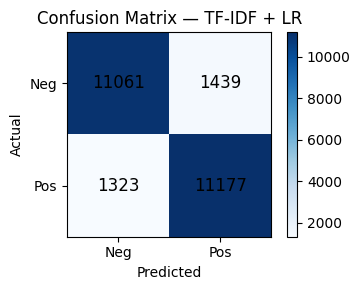

In [34]:
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(4, 3))
    plt.imshow(cm, cmap="Blues")
    plt.title(title)
    plt.colorbar()
    plt.xticks([0, 1], ["Neg", "Pos"])
    plt.yticks([0, 1], ["Neg", "Pos"])
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=12)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(confusion_matrix(y_test, y_pred_lr), "Confusion Matrix — TF-IDF + LR")

## 6. Токенизация для нейросетей (общая для моделей 2 и 3)

In [35]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

VOCAB_SIZE = 20000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_val_pad   = pad_sequences(X_val_seq,   maxlen=max_len, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test_seq,  maxlen=max_len, padding="post", truncating="post")

print(f"Размер словаря: {len(tokenizer.word_index)}")
print(f"X_train_pad shape: {X_train_pad.shape}")

Размер словаря: 67159
X_train_pad shape: (20000, 608)


## 7. BiLSTM с random embeddings

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping

model_lstm = Sequential([
    Embedding(VOCAB_SIZE, 128),
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model_lstm.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model_lstm.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [37]:
early_stop = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

history_lstm = model_lstm.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=128,
    callbacks=[early_stop]
)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 409s 3s/step - accuracy: 0.6977 - loss: 0.5676 - val_accuracy: 0.8344 - val_loss: 0.3958
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 393s 3s/step - accuracy: 0.8329 - loss: 0.3926 - val_accuracy: 0.8470 - val_loss: 0.3686
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 393s 3s/step - accuracy: 0.9046 - loss: 0.2589 - val_accuracy: 0.8710 - val_loss: 0.3416
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 391s 2s/step - accuracy: 0.9445 - loss: 0.1632 - val_accuracy: 0.8674 - val_loss: 0.3549
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 400s 3s/step - accuracy: 0.9615 - loss: 0.1179 - val_accuracy: 0.8678 - val_loss: 0.4231


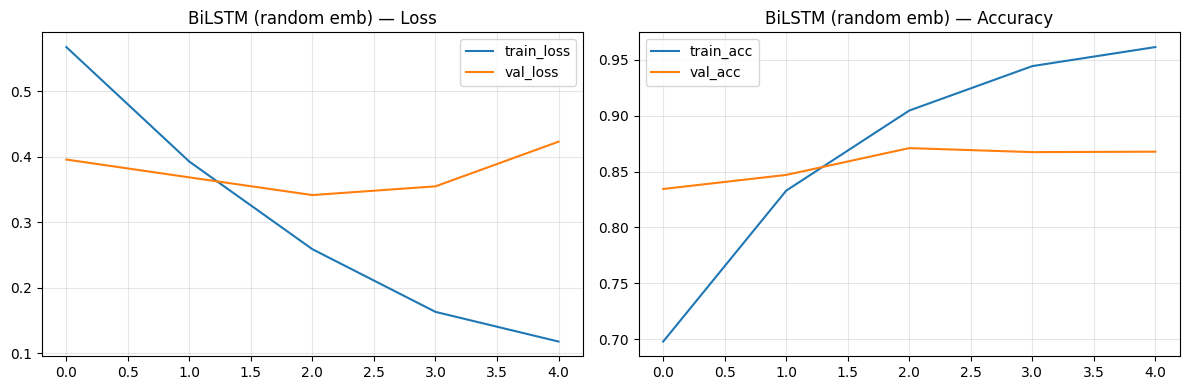

In [38]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history["loss"],     label="train_loss")
    axes[0].plot(history.history["val_loss"], label="val_loss")
    axes[0].set_title(f"{title} — Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    axes[1].plot(history.history["accuracy"],     label="train_acc")
    axes[1].plot(history.history["val_accuracy"], label="val_acc")
    axes[1].set_title(f"{title} — Accuracy")
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_history(history_lstm, "BiLSTM (random emb)")

782/782 ━━━━━━━━━━━━━━━━━━━━ 125s 160ms/step
[BiLSTM — random embeddings]
Accuracy:  0.8527
Precision: 0.8567
Recall:    0.8472
F1:        0.8519


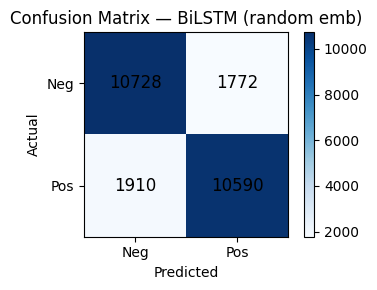

In [39]:
y_pred_lstm = (model_lstm.predict(X_test_pad) > 0.5).astype(int).flatten()
acc_lstm  = accuracy_score(y_test, y_pred_lstm)
prec_lstm, rec_lstm, f1_lstm, _ = precision_recall_fscore_support(y_test, y_pred_lstm, average="binary")

print("[BiLSTM — random embeddings]")
print(f"Accuracy:  {acc_lstm:.4f}")
print(f"Precision: {prec_lstm:.4f}")
print(f"Recall:    {rec_lstm:.4f}")
print(f"F1:        {f1_lstm:.4f}")

plot_confusion_matrix(confusion_matrix(y_test, y_pred_lstm), "Confusion Matrix — BiLSTM (random emb)")

## 8. BiLSTM + GloVe

In [40]:
import urllib.request
import zipfile
import os

if not os.path.exists("glove.6B.100d.txt"):
    print("Скачиваем GloVe (~822 MB)...")
    urllib.request.urlretrieve(
        "https://nlp.stanford.edu/data/glove.6B.zip",
        "glove.6B.zip"
    )
    with zipfile.ZipFile("glove.6B.zip") as z:
        z.extract("glove.6B.100d.txt")
    print("Готово")
else:
    print("GloVe уже скачан")

GloVe уже скачан


In [41]:
EMBED_DIM = 100

embeddings_index = {}
with open("glove.6B.100d.txt", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word   = values[0]
        vector = np.array(values[1:], dtype="float32")
        embeddings_index[word] = vector

print(f"Загружено векторов: {len(embeddings_index)}")

word_index = tokenizer.word_index
embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM))

found = 0
for word, i in word_index.items():
    if i < VOCAB_SIZE:
        vec = embeddings_index.get(word)
        if vec is not None:
            embedding_matrix[i] = vec
            found += 1

total = min(VOCAB_SIZE, len(word_index))
print(f"Покрытие словаря: {found}/{total} ({found/total*100:.1f}%)")

Загружено векторов: 400000
Покрытие словаря: 19859/20000 (99.3%)


In [45]:
model_glove = Sequential([
    Embedding(VOCAB_SIZE, EMBED_DIM,
              weights=[embedding_matrix],
              trainable=False),        # веса GloVe заморожены
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model_glove.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model_glove.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,000,000 (7.63 MB)

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 260s 2s/step - accuracy: 0.5841 - loss: 0.6687 - val_accuracy: 0.5704 - val_loss: 0.6786
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 280s 2s/step - accuracy: 0.5948 - loss: 0.6660 - val_accuracy: 0.7050 - val_loss: 0.5881
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 271s 2s/step - accuracy: 0.6406 - loss: 0.6439 - val_accuracy: 0.6094 - val_loss: 0.6655
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 251s 2s/step - accuracy: 0.7332 - loss: 0.5582 - val_accuracy: 0.7810 - val_loss: 0.4881
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 264s 2s/step - accuracy: 0.7922 - loss: 0.4755 - val_accuracy: 0.8094 - val_loss: 0.4324
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 280s 2s/step - accuracy: 0.8149 - loss: 0.4337 - val_accuracy: 0.8224 - val_loss: 0.4092
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 271s 2s/step - accuracy: 0.8270 - loss: 0.4066 - val_accuracy: 0.8274 - val_loss: 0.3914
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 250s 2s/step - accuracy: 0.8426 - loss: 0.3744 - val_accu

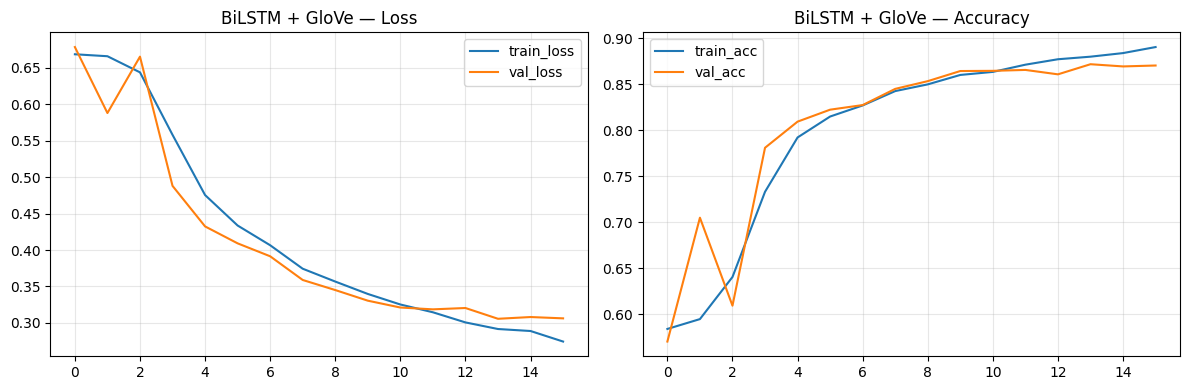

In [46]:
early_stop = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

history_glove = model_glove.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=20,
    batch_size=128,
    callbacks=[early_stop]
)

plot_history(history_glove, "BiLSTM + GloVe")

782/782 ━━━━━━━━━━━━━━━━━━━━ 119s 152ms/step
[BiLSTM + GloVe]
Accuracy:  0.8713
Precision: 0.8667
Recall:    0.8775
F1:        0.8721


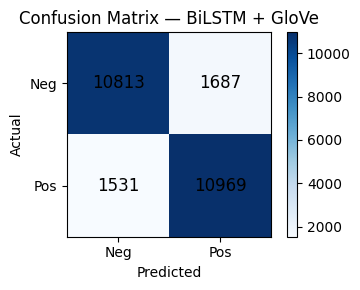

In [47]:
y_pred_glove = (model_glove.predict(X_test_pad) > 0.5).astype(int).flatten()
acc_glove  = accuracy_score(y_test, y_pred_glove)
prec_glove, rec_glove, f1_glove, _ = precision_recall_fscore_support(y_test, y_pred_glove, average="binary")

print("[BiLSTM + GloVe]")
print(f"Accuracy:  {acc_glove:.4f}")
print(f"Precision: {prec_glove:.4f}")
print(f"Recall:    {rec_glove:.4f}")
print(f"F1:        {f1_glove:.4f}")

plot_confusion_matrix(confusion_matrix(y_test, y_pred_glove), "Confusion Matrix — BiLSTM + GloVe")

## 9. Итоговое сравнение моделей

                Модель  Accuracy  Precision  Recall       F1
TF-IDF + LR (baseline)   0.88952   0.885938 0.89416 0.890030
   BiLSTM (random emb)   0.85272   0.856657 0.84720 0.851903
        BiLSTM + GloVe   0.87128   0.866704 0.87752 0.872078


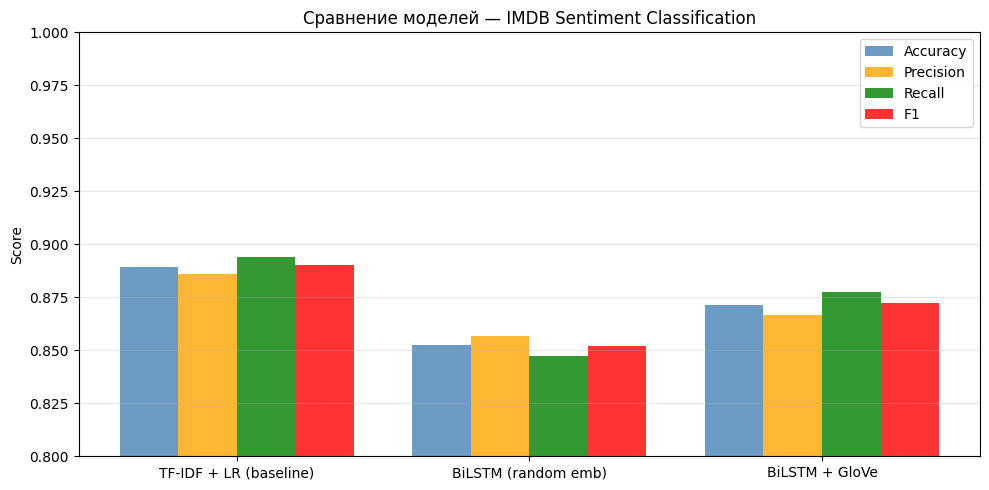

In [48]:
results = pd.DataFrame({
    "Модель":    ["TF-IDF + LR (baseline)", "BiLSTM (random emb)", "BiLSTM + GloVe"],
    "Accuracy":  [acc_lr,   acc_lstm,   acc_glove],
    "Precision": [prec_lr,  prec_lstm,  prec_glove],
    "Recall":    [rec_lr,   rec_lstm,   rec_glove],
    "F1":        [f1_lr,    f1_lstm,    f1_glove],
})

print(results.to_string(index=False))

x = np.arange(len(results))
width = 0.2
metrics = ["Accuracy", "Precision", "Recall", "F1"]
colors  = ["steelblue", "orange", "green", "red"]

fig, ax = plt.subplots(figsize=(10, 5))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i * width, results[metric], width, label=metric, color=color, alpha=0.8)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results["Модель"], fontsize=10)
ax.set_ylim(0.8, 1.0)
ax.set_ylabel("Score")
ax.set_title("Сравнение моделей — IMDB Sentiment Classification")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()